# STalign parity: `merfish-merfish-alignment-simulation.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-merfish-alignment-simulation.ipynb).

Status: `compared`. Both passes skipped 1 cell(s) unrelated to the fit -- cell 33: TypeError: got an unexpected keyword argument 'squared'


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 0.0002432595175732692,
  "extentI relative L2": 0.0,
  "extentJ relative L2": 0.0,
  "tpointsI relative L2": 1.5740866326324597e-06,
  "v relative L2": 1.6727218135598042e-15,
  "xI0 relative L2": 0.0,
  "xI_LDDMM relative L2": 1.9972502602447386e-07,
  "yI0 relative L2": 0.0,
  "yI_LDDMM relative L2": 2.606873261082365e-06
}

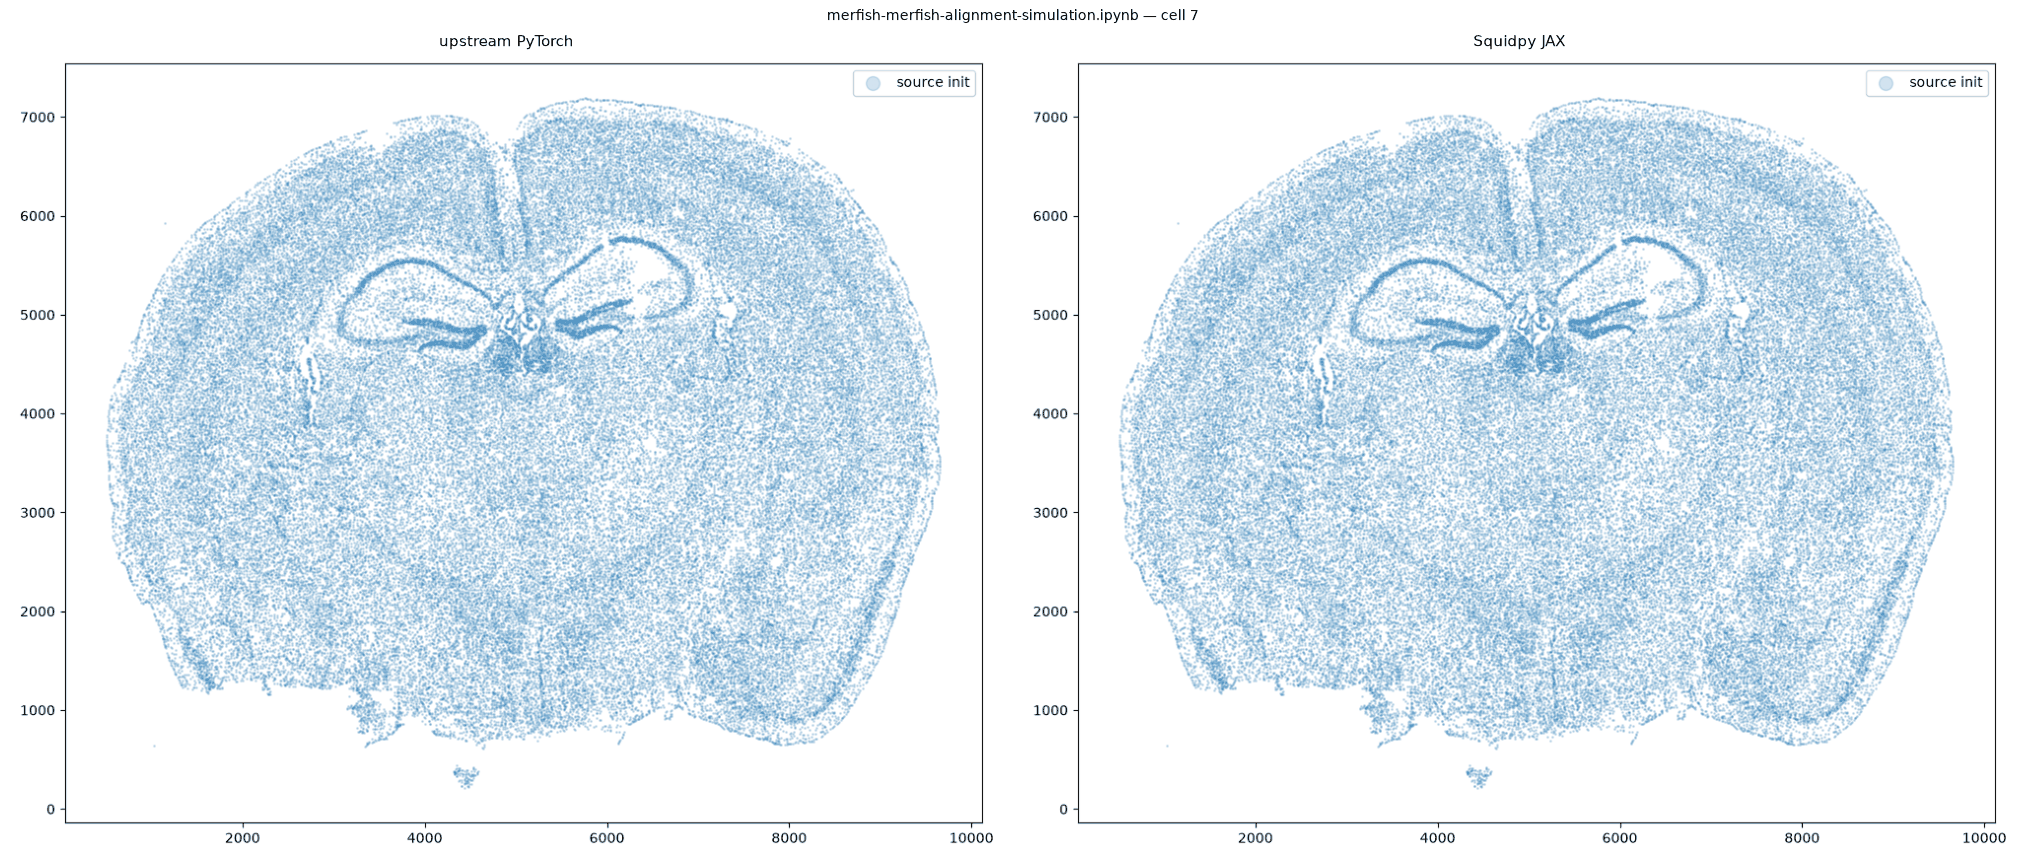

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# make plots bigger
plt.rcParams["figure.figsize"] = (12,10)

# get cell centroid coordinates
xI0 = np.array(df1['center_x'])
yI0 = np.array(df1['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI0,yI0,s=1,alpha=0.2, label='source init')
ax.legend(markerscale = 10)

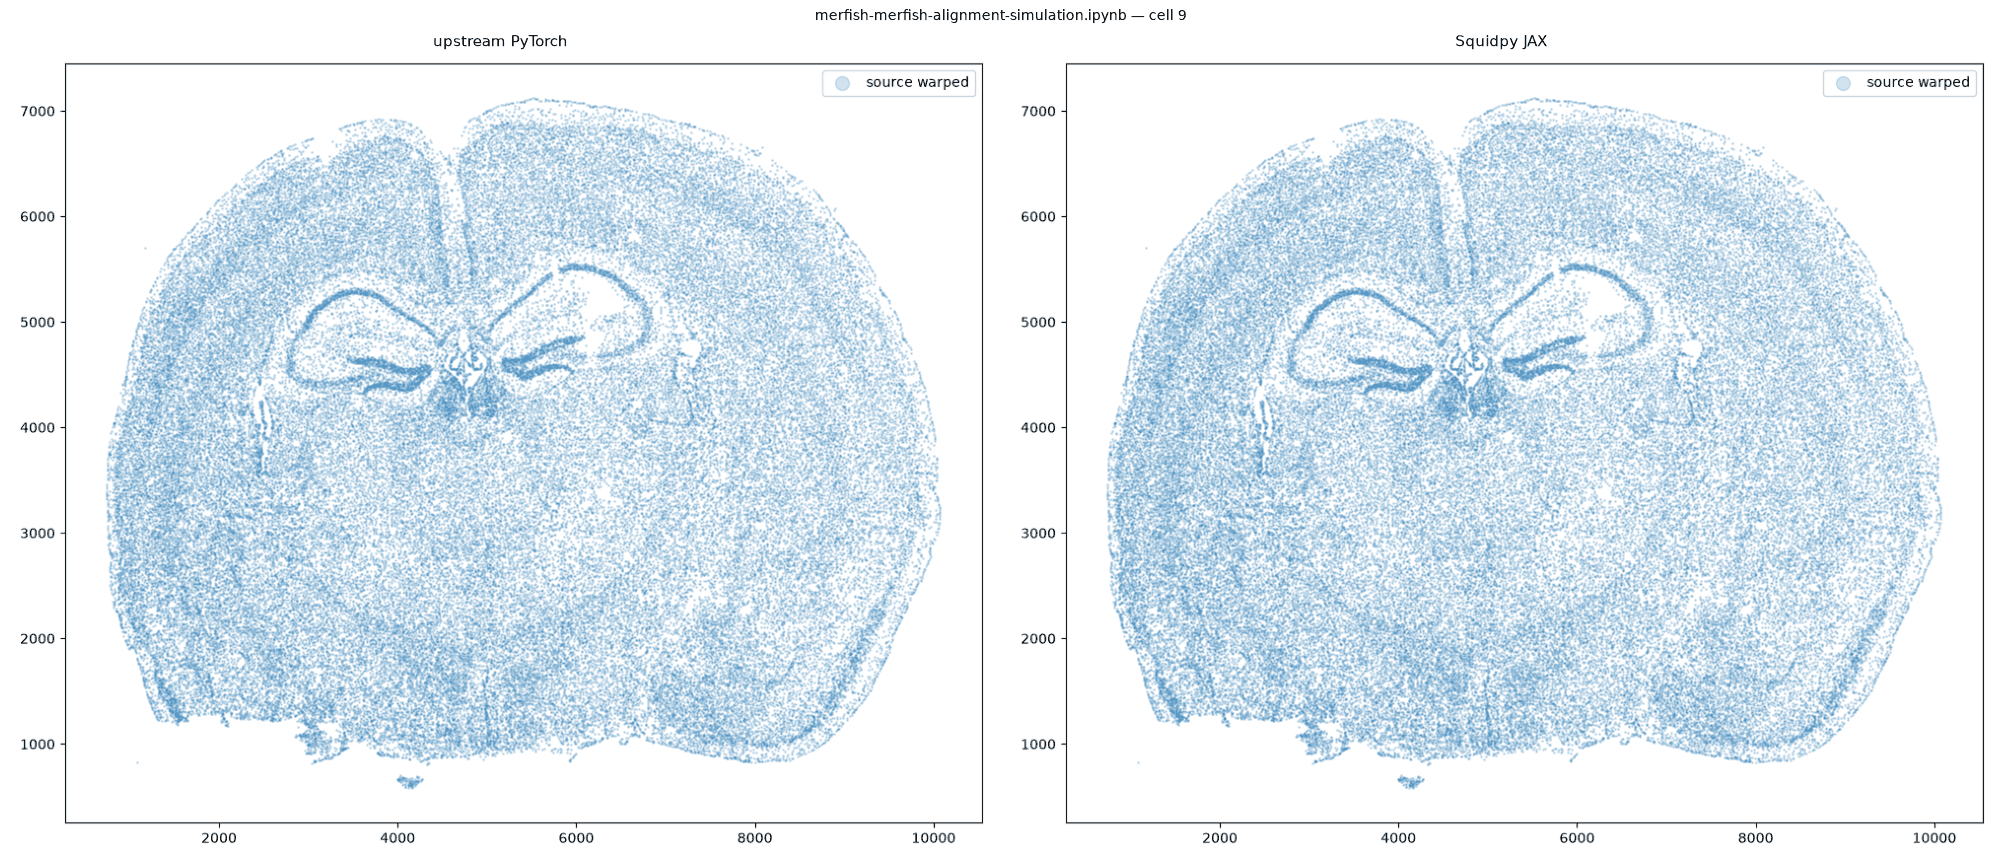

In [3]:
# warp
xI = pow(xI0,1.25)/10+500
yI = pow(yI0,1.25)/10+500

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source warped')
ax.legend(markerscale = 10)

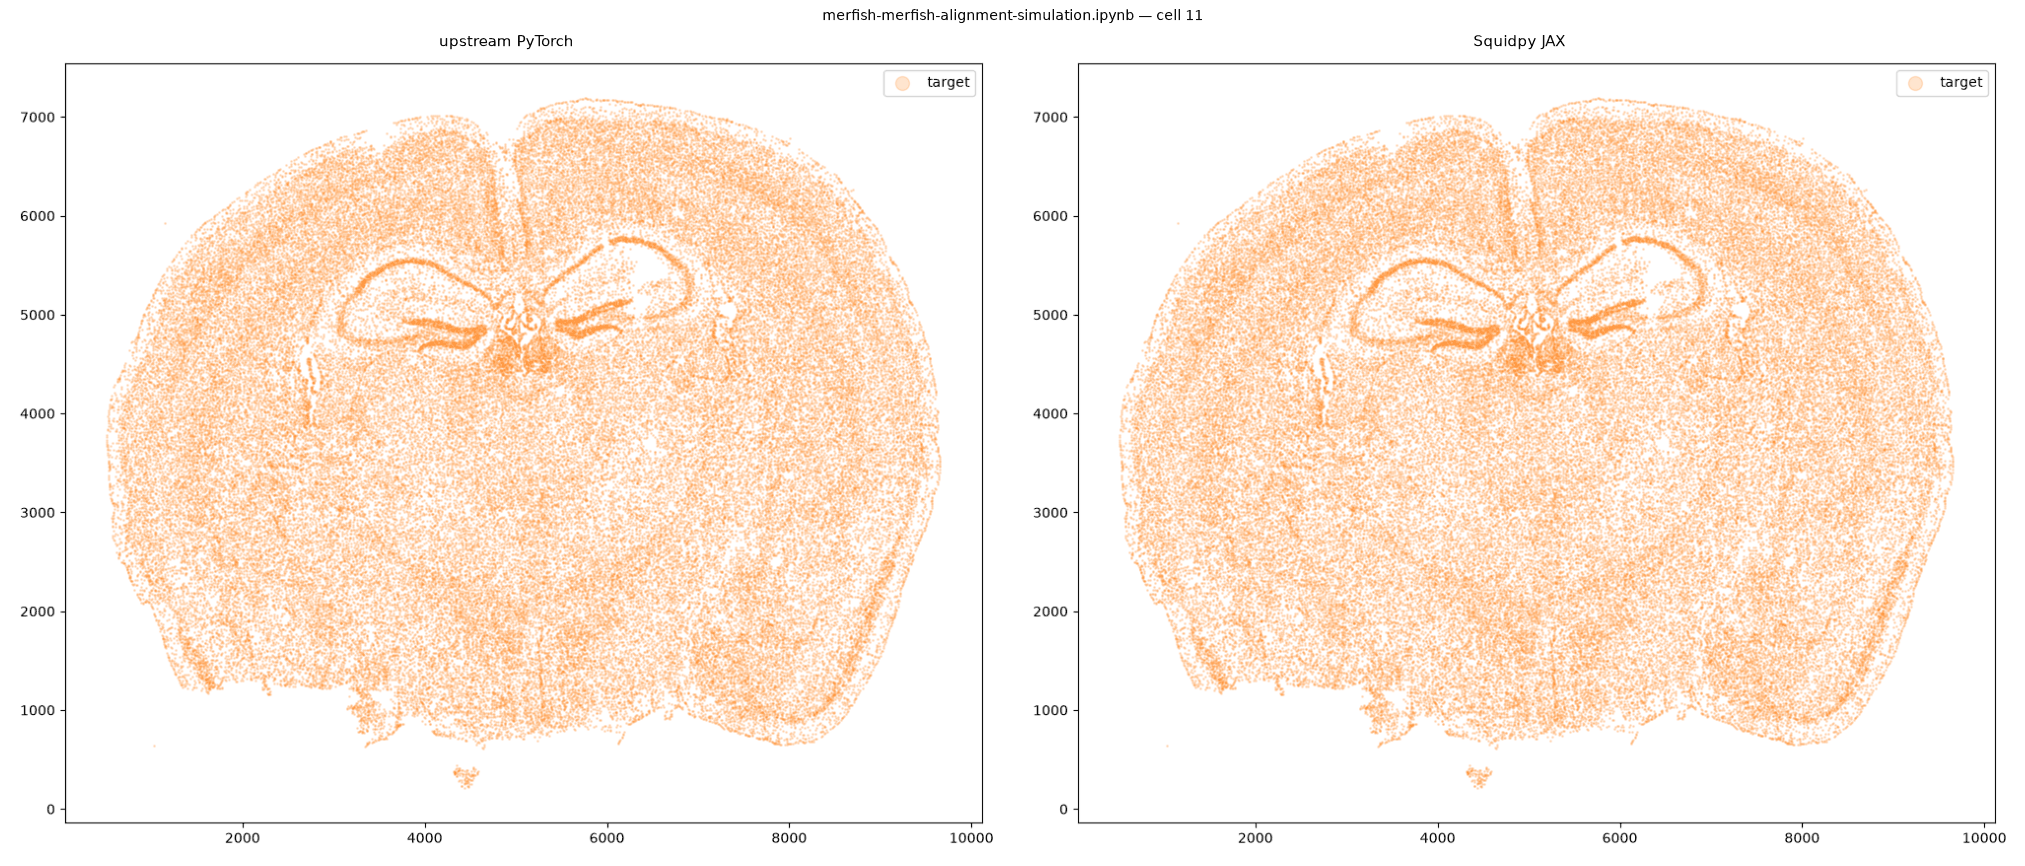

In [4]:
# Single cell data 1
# just original coordinates
xJ = xI0
yJ = yI0

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e', label='target')
ax.legend(markerscale = 10)

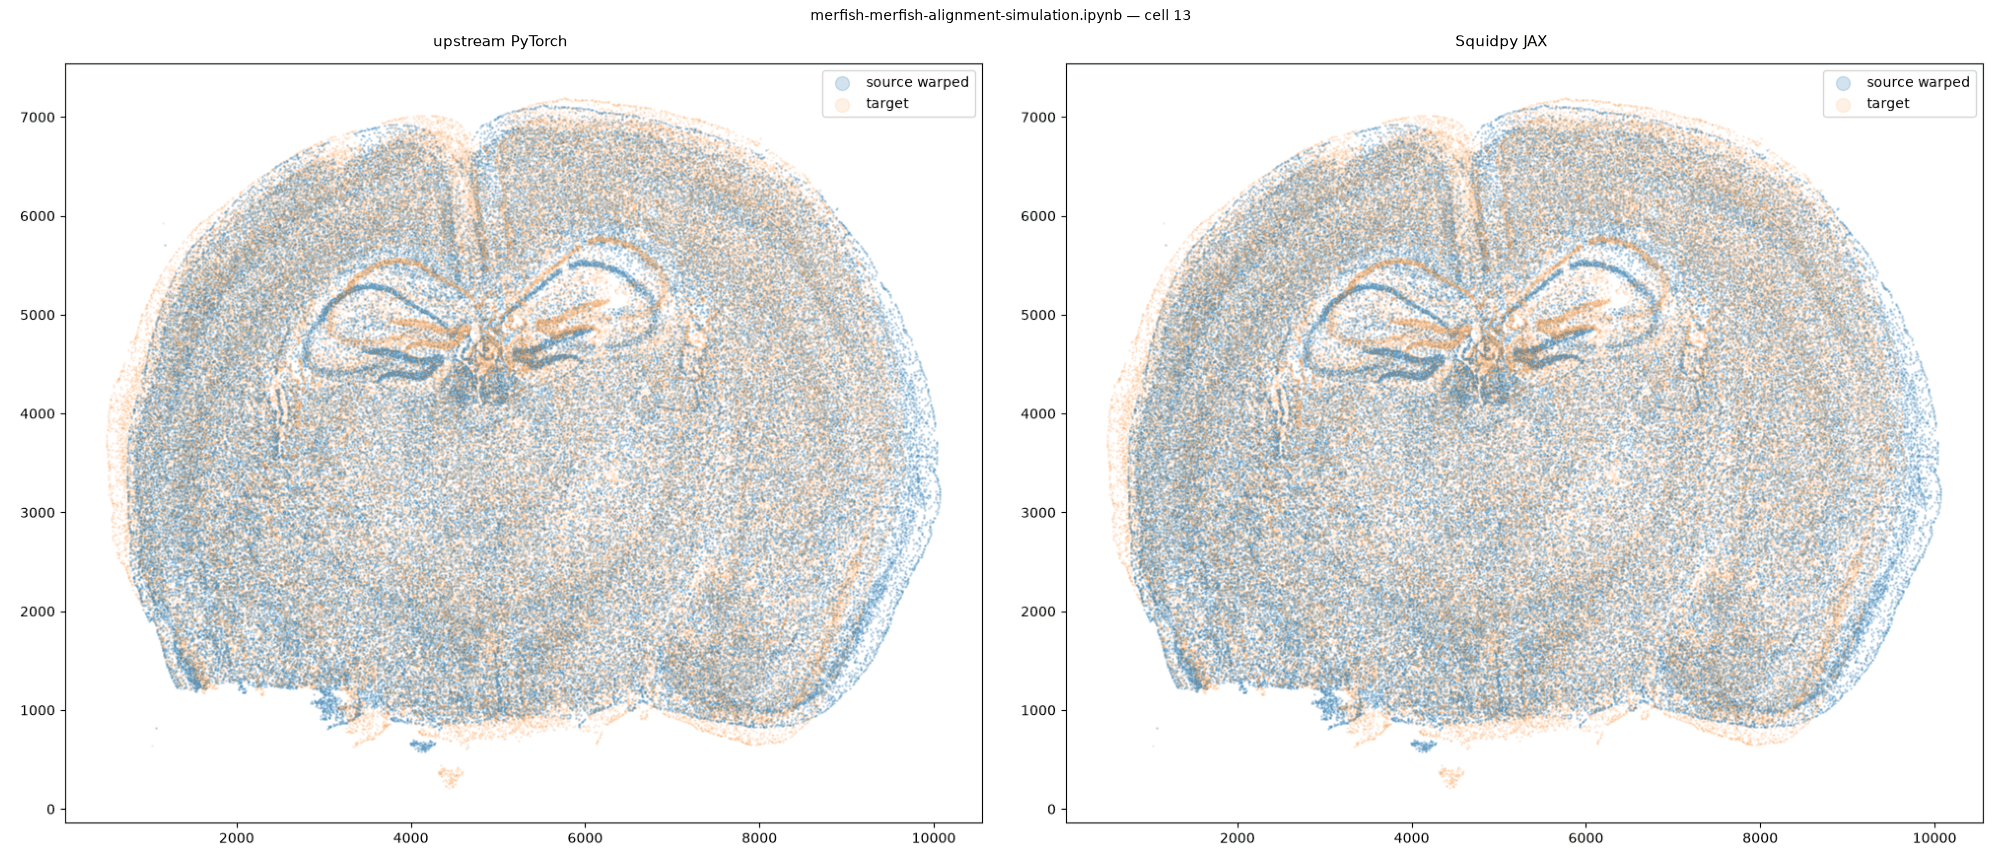

In [5]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source warped')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label= 'target')
ax.legend(markerscale = 10)

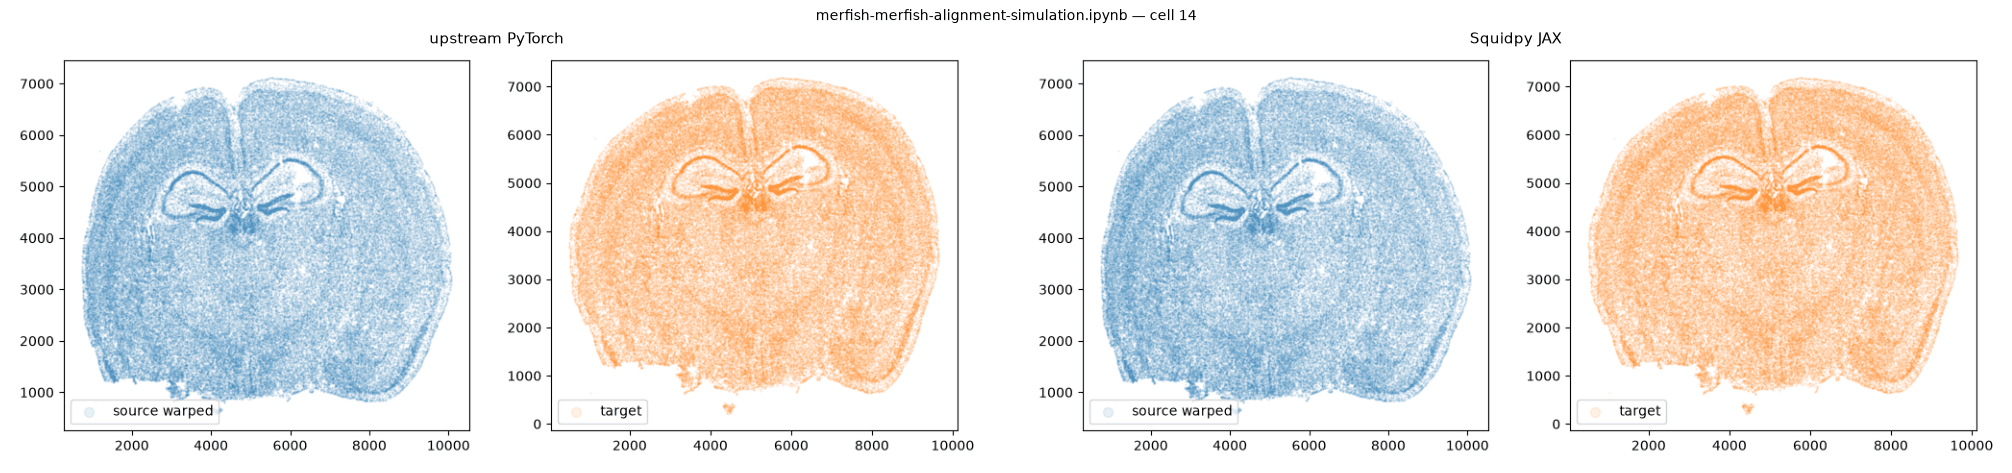

In [6]:
plt.rcParams["figure.figsize"] = (12,5)
fig,ax = plt.subplots(1,2)
ax[0].scatter(xI,yI,s=0.5,alpha=0.1, label='source warped')
ax[1].scatter(xJ,yJ,s=0.5,alpha=0.1, c='#ff7f0e',label='target')
ax[0].legend(markerscale = 10, loc = 'lower left')
ax[1].legend(markerscale = 10, loc = 'lower left')

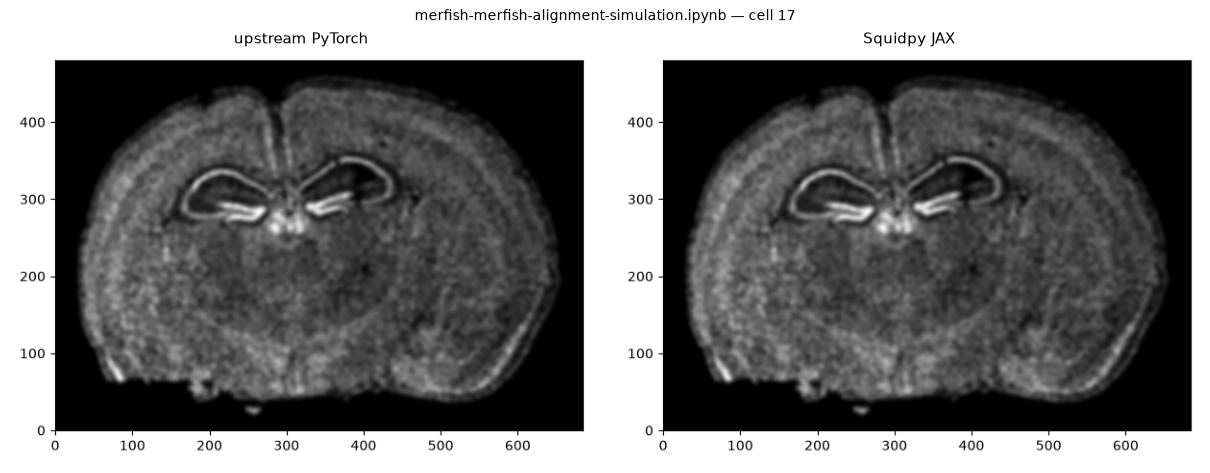

In [7]:
# rasterize at 15um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI,yI,dx=15,blur=1.5)

# plot
ax = fig.axes[0]
ax.invert_yaxis()

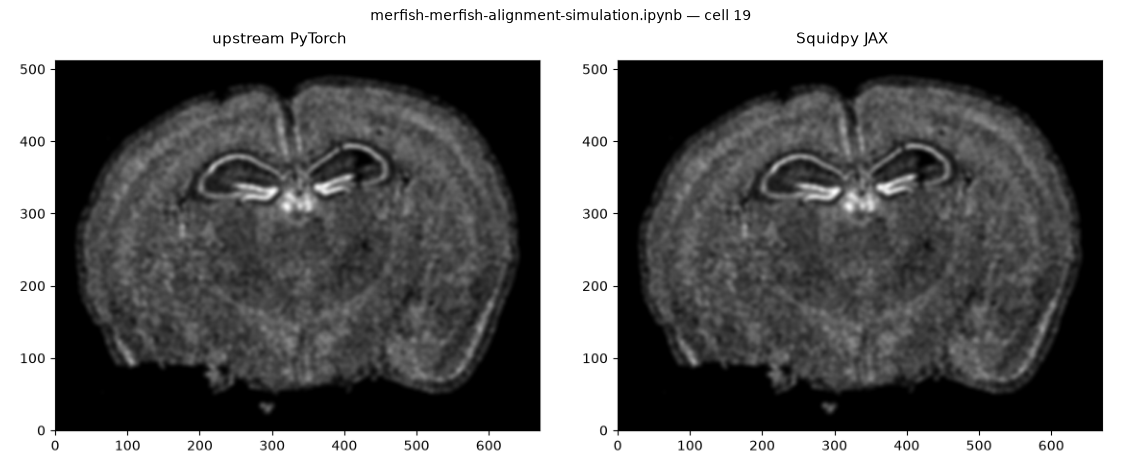

In [8]:
# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=15, blur=1.5)
ax = fig.axes[0]
ax.invert_yaxis()

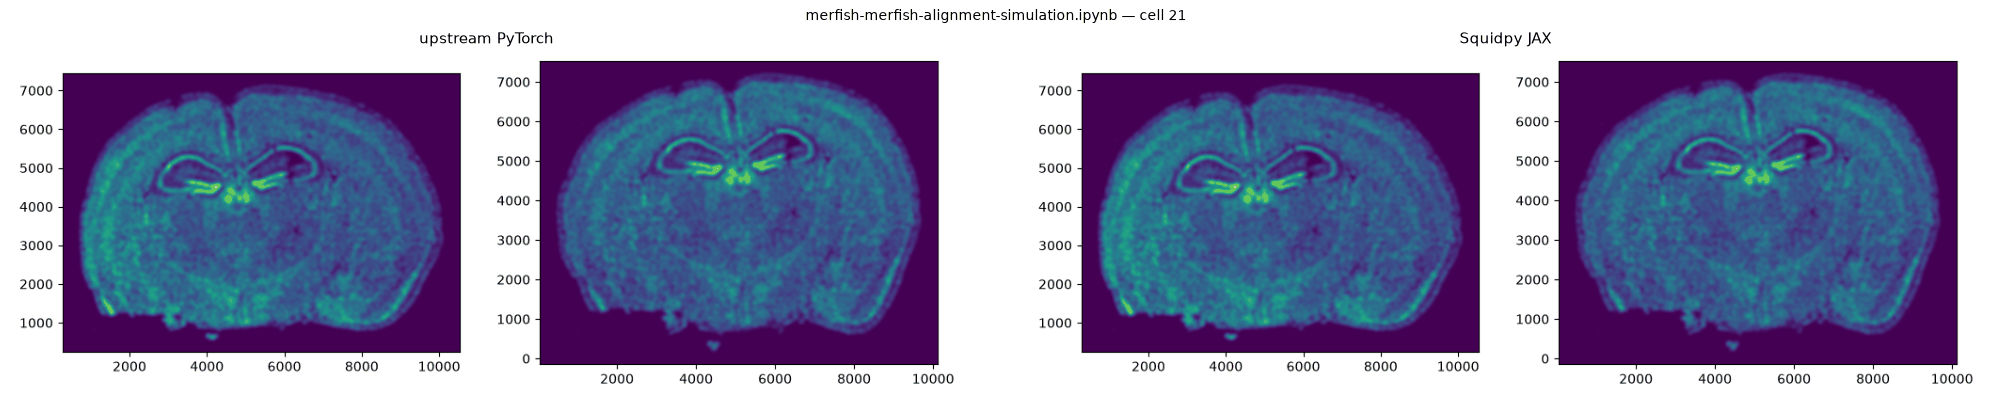

In [9]:
# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

# plot rasterized images
fig,ax = plt.subplots(1,2)
ax[0].imshow(I[0], extent=extentI) 
ax[1].imshow(J[0], extent=extentJ)
ax[0].invert_yaxis()
ax[1].invert_yaxis()

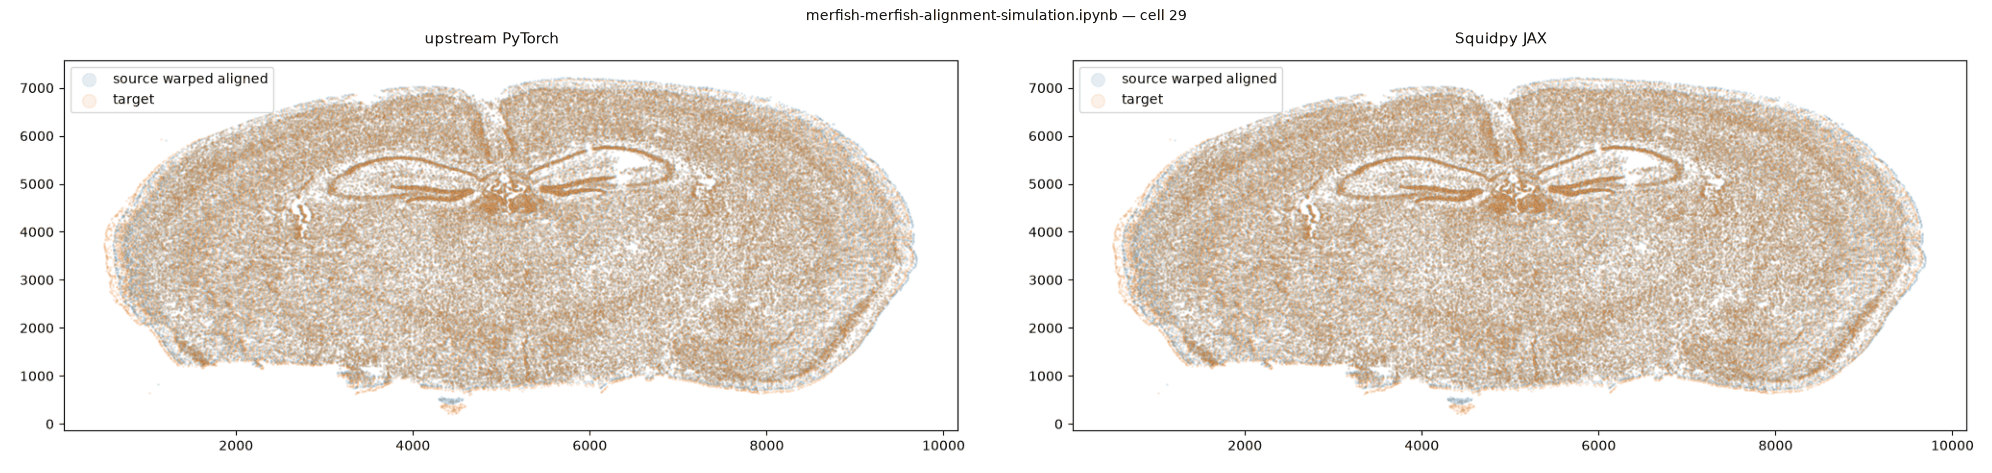

In [10]:
# plot results
fig,ax = plt.subplots()
#ax.scatter(xI,yI,s=1,alpha=0.1, label='source')
ax.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.1, label = 'source warped aligned')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label='target')
ax.legend(markerscale = 10)

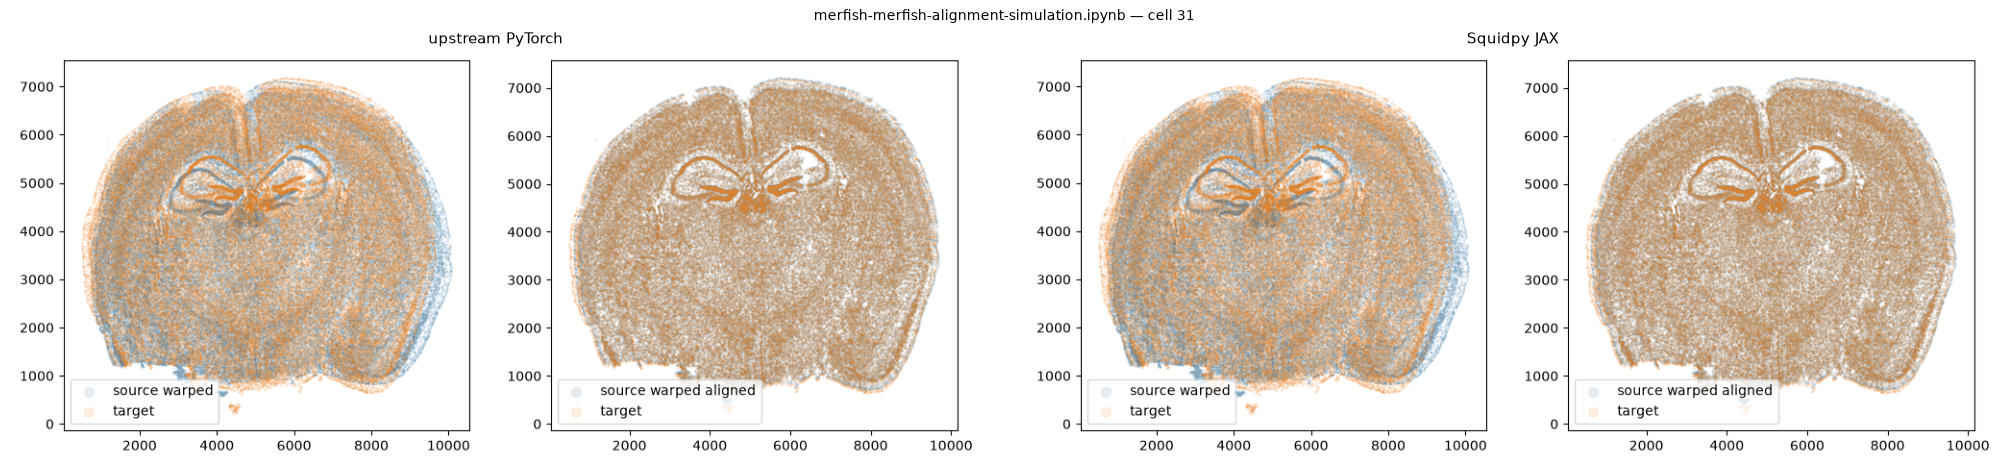

In [11]:
plt.rcParams["figure.figsize"] = (12,5)
fig,ax = plt.subplots(1,2)
ax[0].scatter(xI,yI,s=0.5,alpha=0.1, label='source warped')
ax[0].scatter(xJ,yJ,s=0.5,alpha=0.1, label='target')
ax[1].scatter(xI_LDDMM,yI_LDDMM,s=0.5,alpha=0.1, label = 'source warped aligned') 
ax[1].scatter(xJ,yJ,s=0.5,alpha=0.1, label='target')
ax[0].legend(markerscale = 10, loc = 'lower left')
ax[1].legend(markerscale = 10, loc = 'lower left')